# 15 Review session 2: `pandas`

Pandas provieds a way to represent *structured* data, that is tables of data, where rows or columns are related in some way (think spreadsheets). The main data types are `Series` and `DataFrame`.

* A `Series` is a one-dimensional **labeled** array.
* A `DataFrame` is a two-dimensional labeled array that consists of columns and
rows. A DataFrame can be thought of as a spreadsheet-like data structure where each column represents a Series. DataFrame is a heterogeneous data structure where each column can have a different data type.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget

In [29]:
d1 = pd.Series([1., 2., 3.])
d1
d1[0]

np.float64(1.0)

In [30]:
d2 = pd.Series({'Name':'Marvin', 'Age':12, 'Weight':55})
d2


Name      Marvin
Age           12
Weight        55
dtype: object

In [31]:
dogs = pd.DataFrame(
    {'Name':['Marvin', 'Fluffy', 'Rex'],
    'Age':[12, 8, 4],
     'Weight':[55.0, 40, 20]})
dogs

,Name,Age,Weight
0,Marvin,12,55.0
1,Fluffy,8,40.0
2,Rex,4,20.0


In [32]:
# Each column is a Series:
dogs.Name

0    Marvin
1    Fluffy
2       Rex
Name: Name, dtype: object

In [11]:
type(dogs.Name)

pandas.core.series.Series

In [13]:
# Each row is a series too
dogs.loc[0]

Name      Marvin
Age           12
Weight      55.0
Name: 0, dtype: object

In [ ]:
dogs.loc[0]

In [14]:
# secting a row is a bit clumsy here:
dogs[dogs.Name == 'Marvin']

,Name,Age,Weight
0,Marvin,12,55.0


Maybe we should have *indexed* the dataFrame using the dog names:

In [15]:
dogs2 = pd.DataFrame(
    index = ['Marvin', 'Fluffy', 'Rex'],
    data = {'Age':[12, 8, 4],
     'Weight':[55, 40, 20]})
dogs2

,Age,Weight
Marvin,12,55
Fluffy,8,40
Rex,4,20


In [17]:
dogs2.iloc[0]

Age       12
Weight    55
Name: Marvin, dtype: int64

In [18]:
dogs2.iloc[2]

Age        4
Weight    20
Name: Rex, dtype: int64

Note that we could also have simply changed the index to the name of the dogs:

In [19]:
dogs.set_index('Name')

,Age,Weight
Name,,
Marvin,12,55.0
Fluffy,8,40.0
Rex,4,20.0


## Lets create a DataFrame with random data:

In [33]:
import numpy as np
# number of steps
ns = 101
# number of walks
nw = 5
rndData = np.random.uniform(low = -1, high = 1, size = (ns,nw)).cumsum(axis = 0)
rndData_norm = np.random.normal(loc = 0, scale = 2, size = (ns,nw)).cumsum(axis = 0)


In [34]:
randomWalk = pd.DataFrame(data = rndData, columns = [f'w{i}' for i in range(nw)])
randomWalk_norm = pd.DataFrame(data = rndData_norm, columns = [f'w{i}' for i in range(nw)])
randomWalk.head()

,w0,w1,w2,w3,w4
0,0.274608,0.889226,-0.797614,0.720782,-0.628300
1,0.792235,0.725058,-0.605356,1.056011,0.112618
2,1.524316,0.017158,0.279290,0.312722,-0.314494
3,0.709767,0.830267,-0.377198,-0.396426,-0.064275
4,-0.170098,1.614998,0.360012,0.392848,0.428144


In [35]:
import datetime as dt
t = [dt.datetime(year = 2026, month = 1, day = 1) + dt.timedelta(hours = k*6) for k in range(ns)]
t[:5]

[datetime.datetime(2026, 1, 1, 0, 0),
 datetime.datetime(2026, 1, 1, 6, 0),
 datetime.datetime(2026, 1, 1, 12, 0),
 datetime.datetime(2026, 1, 1, 18, 0),
 datetime.datetime(2026, 1, 2, 0, 0)]

In [36]:
randomWalk.insert(0,"Time", t)
randomWalk_norm.insert(0,"Time",t)

In [37]:
randomWalk.set_index("Time")
randomWalk_norm.set_index("Time")
randomWalk.head()

,Time,w0,w1,w2,w3,w4
0,2026-01-01 00:00:00,0.274608,0.889226,-0.797614,0.720782,-0.628300
1,2026-01-01 06:00:00,0.792235,0.725058,-0.605356,1.056011,0.112618
2,2026-01-01 12:00:00,1.524316,0.017158,0.279290,0.312722,-0.314494
3,2026-01-01 18:00:00,0.709767,0.830267,-0.377198,-0.396426,-0.064275
4,2026-01-02 00:00:00,-0.170098,1.614998,0.360012,0.392848,0.428144


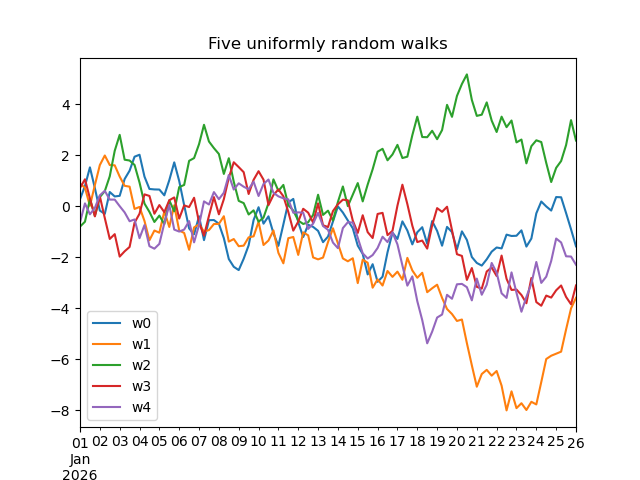

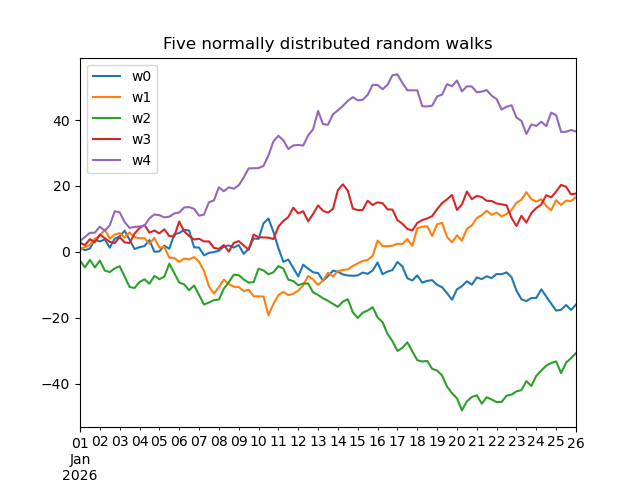

In [38]:
p = randomWalk.plot(x='Time', title = 'Five uniformly random walks')
q = randomWalk_norm.plot(x = "Time", title = 'Five normally distributed random walks')

## Reading from csv files
Let's pull a data set on mean surface air temperature since 1880 from [NASA Goddard](https://data.giss.nasa.gov/gistemp/graphs_v4/)

In [39]:
url = 'https://data.giss.nasa.gov/gistemp/graphs_v4/graph_data/Global_Mean_Estimates_based_on_Land_and_Ocean_Data/graph.csv'

temp = pd.read_csv(url, skiprows = 1)
temp.set_index('Year')
temp.head()

,Year,No_Smoothing,Lowess(5)
0,1880,-0.17,-0.10
1,1881,-0.09,-0.13
2,1882,-0.11,-0.17
3,1883,-0.18,-0.21
4,1884,-0.28,-0.24


<Axes: xlabel='Year'>

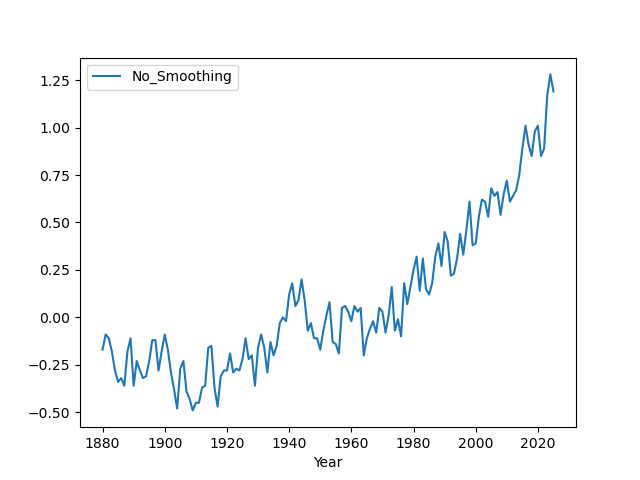

In [40]:
temp.plot(x = 'Year', y = 'No_Smoothing')

Text(0.5, 1.0, 'Temperature fluctuations from norm 1880 - 2020')

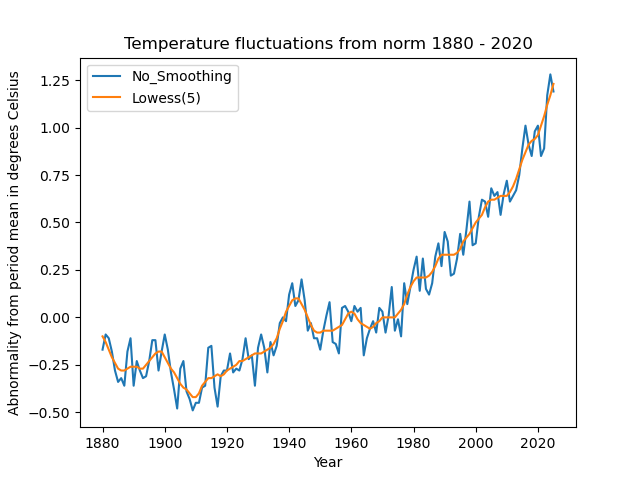

In [41]:
p = temp.plot(x = 'Year', ylabel= 'Abnormality from period mean in degrees Celsius')
p.set_title('Temperature fluctuations from norm 1880 - 2020')
